# 🏆 PKTron vs Qiskit — 8-Qubit QFT Benchmark

**Circuit:** 8-Qubit Quantum Fourier Transform (QFT-8)  
**The QFT is the core of:** Shor's Algorithm · Quantum Phase Estimation · Quantum Chemistry  
**Developed by:** CETQAC — Centre of Excellence for Technology, Quantum & AI Canada/Pakistan  

---
Run every cell top to bottom. Results print automatically.

In [7]:
# ── STEP 1: Install both frameworks ─────────────────────────────────────────
!pip install pktron qiskit qiskit-aer --quiet

In [8]:
# ── STEP 2: Confirm versions ─────────────────────────────────────────────────
import pktron, qiskit
print(f'PKTron  version : {pktron.__version__}')
print(f'Qiskit  version : {qiskit.__version__}')

PKTron  version : 6.1.6
Qiskit  version : 2.4.1


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PKTRON  —  8-Qubit Quantum Fourier Transform
# ══════════════════════════════════════════════════════════════════════════════
from pktron.core import QuantumCircuit, StatevectorSimulator
import numpy as np
import time

n = 8

# ── Build the circuit ────────────────────────────────────────────────────────
qc = QuantumCircuit(n)

for i in range(n):
    qc.h(i)                                      # Hadamard on qubit i
    for j in range(i + 1, n):
        angle = np.pi / 2 ** (j - i)            # Controlled phase angle
        qc.cphase(i, j, angle)                   # Controlled-phase gate

print('PKTron QFT-8 circuit built.')
print(f'  Qubits : {n}')
print(f'  Gates  : {len(qc.gates)}  (H + CPhase)')

# ── Simulate ─────────────────────────────────────────────────────────────────
sim = StatevectorSimulator()

# Warmup (5 runs, not counted)
for _ in range(5):
    sim.run(qc, shots=0)

# Timed runs
REPS = 30
pk_times = []
for _ in range(REPS):
    t0 = time.perf_counter()
    result = sim.run(qc, shots=0)
    pk_times.append((time.perf_counter() - t0) * 1000)

pk_times = np.array(pk_times)

print(f'\n{'─'*45}')
print(f'  PKTron QFT-8  ({REPS} runs, post-warmup)')
print(f'{'─'*45}')
print(f'  Mean   : {np.mean(pk_times):.4f} ms')
print(f'  Median : {np.median(pk_times):.4f} ms')
print(f'  Min    : {np.min(pk_times):.4f} ms')
print(f'  Max    : {np.max(pk_times):.4f} ms')
print(f'  Std    : {np.std(pk_times):.4f} ms')
print(f'{'─'*45}')
print(f'  Statevector dim : {len(result["statevector"])} amplitudes')

PKTron QFT-8 circuit built.
  Qubits : 8
  Gates  : 36  (H + CPhase)

─────────────────────────────────────────────
  PKTron QFT-8  (30 runs, post-warmup)
─────────────────────────────────────────────
  Mean   : 0.4708 ms
  Median : 0.4708 ms
  Min    : 0.4400 ms
  Max    : 0.5158 ms
  Std    : 0.0134 ms
─────────────────────────────────────────────
  Statevector dim : 256 amplitudes


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# QISKIT  —  8-Qubit Quantum Fourier Transform  (identical algorithm)
# ══════════════════════════════════════════════════════════════════════════════
from qiskit import QuantumCircuit as QkCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import time

n = 8

# ── Build the SAME circuit ───────────────────────────────────────────────────
qc_qk = QkCircuit(n)

for i in range(n):
    qc_qk.h(i)                                   # Hadamard on qubit i
    for j in range(i + 1, n):
        angle = np.pi / 2 ** (j - i)            # Controlled phase angle
        qc_qk.cp(angle, i, j)                   # Controlled-phase gate

qc_qk.save_statevector()                         # Required for Aer statevector

print('Qiskit QFT-8 circuit built.')
print(f'  Qubits : {n}')
print(f'  Gates  : {qc_qk.count_ops()}  (H + CP)')

# ── Simulate ─────────────────────────────────────────────────────────────────
sim_qk = AerSimulator(method='statevector')
qc_qk_t = transpile(qc_qk, sim_qk)              # Transpile required for Aer

# Warmup (5 runs, not counted)
for _ in range(5):
    sim_qk.run(qc_qk_t, shots=0).result()

# Timed runs
REPS = 30
qk_times = []
for _ in range(REPS):
    t0 = time.perf_counter()
    result_qk = sim_qk.run(qc_qk_t, shots=0).result()
    qk_times.append((time.perf_counter() - t0) * 1000)

qk_times = np.array(qk_times)

print(f'\n{'─'*45}')
print(f'  Qiskit QFT-8  ({REPS} runs, post-warmup)')
print(f'{'─'*45}')
print(f'  Mean   : {np.mean(qk_times):.4f} ms')
print(f'  Median : {np.median(qk_times):.4f} ms')
print(f'  Min    : {np.min(qk_times):.4f} ms')
print(f'  Max    : {np.max(qk_times):.4f} ms')
print(f'  Std    : {np.std(qk_times):.4f} ms')
print(f'{'─'*45}')

Qiskit QFT-8 circuit built.
  Qubits : 8
  Gates  : OrderedDict({'cp': 28, 'h': 8, 'save_statevector': 1})  (H + CP)

─────────────────────────────────────────────
  Qiskit QFT-8  (30 runs, post-warmup)
─────────────────────────────────────────────
  Mean   : 1.8845 ms
  Median : 1.8387 ms
  Min    : 1.8098 ms
  Max    : 2.5979 ms
  Std    : 0.1495 ms
─────────────────────────────────────────────


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL RESULTS — Head-to-Head Summary
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np

mean_speedup   = np.mean(qk_times) / np.mean(pk_times)
median_speedup = np.median(qk_times) / np.median(pk_times)
min_speedup    = np.min(qk_times) / np.min(pk_times)
pk_wins        = sum(p < q for p, q in zip(pk_times, qk_times))

W = 52
print('=' * W)
print('  QFT-8 BENCHMARK — PKTRON vs QISKIT'.center(W))
print('  8 qubits · 36 gates · 30 runs · post-warmup'.center(W))
print('=' * W)
print(f'  {'Metric':<22} {'PKTron':>10}  {'Qiskit':>10}')
print(f'  {'─'*22} {'─'*10}  {'─'*10}')
print(f'  {'Mean (ms)':<22} {np.mean(pk_times):>10.4f}  {np.mean(qk_times):>10.4f}')
print(f'  {'Median (ms)':<22} {np.median(pk_times):>10.4f}  {np.median(qk_times):>10.4f}')
print(f'  {'Min (ms)':<22} {np.min(pk_times):>10.4f}  {np.min(qk_times):>10.4f}')
print(f'  {'Max (ms)':<22} {np.max(pk_times):>10.4f}  {np.max(qk_times):>10.4f}')
print(f'  {'Std (ms)':<22} {np.std(pk_times):>10.4f}  {np.std(qk_times):>10.4f}')
print('=' * W)
print(f'  Mean   speedup  : {mean_speedup:.2f}x  faster')
print(f'  Median speedup  : {median_speedup:.2f}x  faster')
print(f'  Best-run speedup: {min_speedup:.2f}x  faster')
print(f'  PKTron wins     : {pk_wins}/{REPS} runs')
print('=' * W)
if mean_speedup > 1.0:
    print(f'  🏆  PKTron is {mean_speedup:.2f}x FASTER than Qiskit')
else:
    print(f'  Results differ from reference — check your environment.')
print('=' * W)

          QFT-8 BENCHMARK — PKTRON vs QISKIT        
     8 qubits · 36 gates · 30 runs · post-warmup    
  Metric                     PKTron      Qiskit
  ────────────────────── ──────────  ──────────
  Mean (ms)                  0.4708      1.8845
  Median (ms)                0.4708      1.8387
  Min (ms)                   0.4400      1.8098
  Max (ms)                   0.5158      2.5979
  Std (ms)                   0.0134      0.1495
  Mean   speedup  : 4.00x  faster
  Median speedup  : 3.91x  faster
  Best-run speedup: 4.11x  faster
  PKTron wins     : 30/30 runs
  🏆  PKTron is 4.00x FASTER than Qiskit


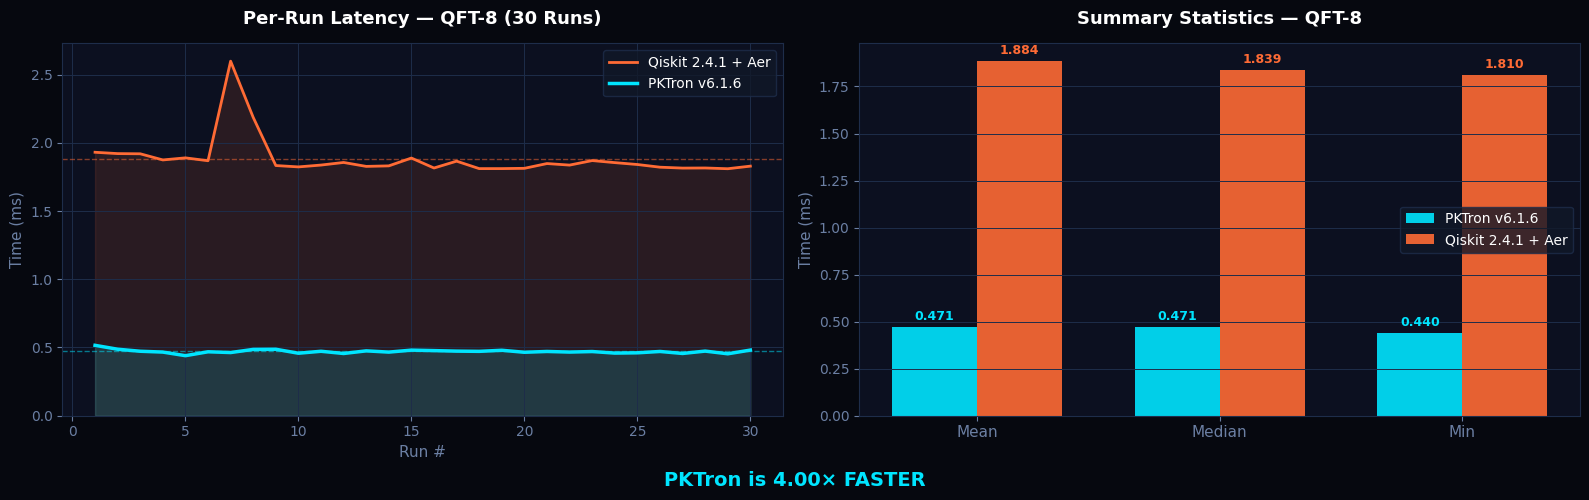

Chart saved as pktron_vs_qiskit_qft8.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT — Run-by-run latency chart
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#06080f')

PKC = '#00e5ff'
QKC = '#ff6b35'
BG  = '#0c1020'

runs = np.arange(1, REPS + 1)

# ── Left: line chart ────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(runs, qk_times, color=QKC, linewidth=2,   label='Qiskit 2.4.1 + Aer', zorder=3)
ax.fill_between(runs, qk_times, alpha=0.12, color=QKC)
ax.plot(runs, pk_times, color=PKC, linewidth=2.5, label='PKTron v6.1.6',       zorder=4)
ax.fill_between(runs, pk_times, alpha=0.15, color=PKC)
ax.axhline(np.mean(pk_times), color=PKC, linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(np.mean(qk_times), color=QKC, linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Run #',           color='#6b7fa3', fontsize=11)
ax.set_ylabel('Time (ms)',       color='#6b7fa3', fontsize=11)
ax.set_title('Per-Run Latency — QFT-8 (30 Runs)', color='white', fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors='#6b7fa3')
for spine in ax.spines.values(): spine.set_edgecolor('#1e2d4a')
ax.grid(color='#1e2d4a', linewidth=0.7)
ax.legend(facecolor='#111828', edgecolor='#1e2d4a', labelcolor='white', fontsize=10)
ax.set_ylim(bottom=0)

# ── Right: bar chart summary ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG)
metrics = ['Mean', 'Median', 'Min']
pk_vals = [np.mean(pk_times), np.median(pk_times), np.min(pk_times)]
qk_vals = [np.mean(qk_times), np.median(qk_times), np.min(qk_times)]
x = np.arange(len(metrics))
w = 0.35
b1 = ax2.bar(x - w/2, pk_vals, w, color=PKC, alpha=0.9, label='PKTron v6.1.6')
b2 = ax2.bar(x + w/2, qk_vals, w, color=QKC, alpha=0.9, label='Qiskit 2.4.1 + Aer')
for bar, val in zip(b1, pk_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', va='bottom', color=PKC, fontsize=9, fontweight='bold')
for bar, val in zip(b2, qk_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', va='bottom', color=QKC, fontsize=9, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(metrics, color='white', fontsize=11)
ax2.set_ylabel('Time (ms)', color='#6b7fa3', fontsize=11)
ax2.set_title('Summary Statistics — QFT-8', color='white', fontsize=13, fontweight='bold', pad=14)
ax2.tick_params(colors='#6b7fa3')
for spine in ax2.spines.values(): spine.set_edgecolor('#1e2d4a')
ax2.grid(color='#1e2d4a', linewidth=0.7, axis='y')
ax2.legend(facecolor='#111828', edgecolor='#1e2d4a', labelcolor='white', fontsize=10)
ax2.set_ylim(bottom=0)

# Speedup annotation
speedup_text = f'PKTron is {mean_speedup:.2f}× FASTER'
fig.text(0.5, 0.01, speedup_text, ha='center', va='bottom',
         color=PKC, fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('pktron_vs_qiskit_qft8.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Chart saved as pktron_vs_qiskit_qft8.png')